# False positive and detection rates of recombinant detection vs k

The paper chooses $k = 4$ on qualitative grounds: $k = 3$ gave "many dubious
recombination events", $k = 5$ "failed to include the well supported recombination
events documented in" Jackson et al. Those are a false positive claim and a false
negative claim. This quantifies both.

Synthetic single-breakpoint recombinants are spliced from pairs of real UK sequences
collected on 2021-05-16, and matched against the raw inference ARG for 2021-05-15 with
`sc2ts run-hmm`. Real sequences held out of the parent pool act as non-recombinant
controls, so a control matched to more than one parent is a false positive.

Two crosses bracket the range of parent divergence seen in the real ARG. Alpha x Alpha
parents sit at pangonet distance 0, like the 31% of real recombinants whose parents
share a lineage; Alpha x Delta sit at 4-5, against a real median of 2.

Each parent is also given random mutations before splicing, to model parents that were
not themselves sampled: none (0x), the number expected in one transmission generation
(1x, as if every case were sequenced), or five or ten times that (5x and 10x, one case
in five or ten). Controls get the same. The sections up to "Unsampled parents" use the 0x arm alone.

See `simulations/synthetic_recombinants/` for the workflow.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scipy.stats

In [2]:
results_dir = Path("../simulations/synthetic_recombinants")
df_all = pd.read_csv(results_dir / "results.csv")
# Only recombinants matched with two parents have these, so they arrive as
# object columns with blanks.
for column in [
    "breakpoint_in_interval",
    "net_min_supporting_loci_lft_rgt_ge_4",
    "left_pango_correct",
    "right_pango_correct",
]:
    df_all[column] = df_all[column].astype("boolean")

# How many sites separate the parents on the sparser side of the true breakpoint.
# This is the signal available to the HMM, known by construction.
df_all["min_informative"] = np.minimum(
    df_all.num_informative_left, df_all.num_informative_right
)
multipliers = sorted(df_all.mutation_multiplier.unique())

# Parents and controls exactly as sampled.
df = df_all[df_all.mutation_multiplier == 0]

recombinants = df[df.type == "recombinant"]
controls = df[df.type == "control"]
k_values = sorted(df.k.unique())
crosses = list(recombinants.cross.unique())
len(df), k_values, crosses

(4014, [np.int64(3), np.int64(4), np.int64(5)], ['AlphaxAlpha', 'AlphaxDelta'])

In [3]:
# k is ordered, so one hue stepped light to dark. Crosses are unordered, so two
# distinct hues.
k_colors = dict(zip(k_values, ["#86b6ef", "#2a78d6", "#104281"]))
cross_colors = dict(zip(crosses, ["#2a78d6", "#eb6834"]))
# Controls are the reference class, not a third category, so they take neutral
# ink rather than a hue of their own.
control_color = "#52514e"
grid_kwargs = dict(color="0.9", linewidth=0.6)

# The paper's own thresholds, for reference throughout.
QC_COLUMN = "net_min_supporting_loci_lft_rgt_ge_4"
QC_CUTOFF = 4
HMM_COST_THRESHOLD = 7
PAPER_MEDIAN_INTERVAL = 2018


def clean_axes(ax):
    ax.yaxis.grid(True, **grid_kwargs)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

## False positives

Controls are real, non-recombinant sequences. Any matched to more than one parent is a
false positive. `fp_upper_95` is the one-sided Clopper-Pearson upper bound, which is
what the number of controls actually buys.

In [4]:
rows = []
for k in k_values:
    ctl = controls[controls.k == k]
    n_fp = int(ctl.detected.sum())
    rows.append(
        {
            "k": k,
            "n_controls": len(ctl),
            "false_positives": n_fp,
            "fp_rate": n_fp / len(ctl),
            "fp_upper_95": scipy.stats.beta.ppf(0.95, n_fp + 1, len(ctl) - n_fp),
            "fp_passing_qc": int(ctl[QC_COLUMN].fillna(False).sum()),
            "median_cost": ctl.hmm_cost.median(),
        }
    )
false_positives = pd.DataFrame(rows).set_index("k")
false_positives.round(3)

,n_controls,false_positives,fp_rate,fp_upper_95,fp_passing_qc,median_cost
k,,,,,,
3,338,0,0.0,0.009,0,0.0
4,338,0,0.0,0.009,0,0.0
5,338,0,0.0,0.009,0,0.0


## Detection

`detection_rate` is unconditional. `qc_pass_rate` is the fraction of *detected*
recombinants that clear the paper's QC gate of at least 4 net supporting loci on both
flanks — the filter that leaves 647 of 1,319 real events. `breakpoint_in_interval` is
how often the true breakpoint falls inside the inferred interval.

In [5]:
rows = []
for (cross, k), group in recombinants.groupby(["cross", "k"]):
    detected = group[group.detected]
    rows.append(
        {
            "cross": cross,
            "k": k,
            "n": len(group),
            "detection_rate": group.detected.mean(),
            "qc_pass_rate": detected[QC_COLUMN].mean(),
            "breakpoint_in_interval": detected.breakpoint_in_interval.mean(),
            "median_interval_width": detected.interval_width.median(),
            "median_net_loci": np.minimum(
                detected.net_min_supporting_loci_lft,
                detected.net_min_supporting_loci_rgt,
            ).median(),
            "median_cost": group.hmm_cost.median(),
            "parent_distance": group.parent_pangonet_distance.median(),
        }
    )
detection = pd.DataFrame(rows).set_index(["cross", "k"])
detection.round(3)

n  detection_rate  qc_pass_rate  breakpoint_in_interval  \
cross       k                                                              
AlphaxAlpha 3  500           0.620         0.706                   0.965   
            4  500           0.400         0.995                   0.995   
            5  500           0.208         1.000                   1.000   
AlphaxDelta 3  500           0.924         0.961                   0.985   
            4  500           0.888         1.000                   0.984   
            5  500           0.846         1.000                   0.983   

               median_interval_width  median_net_loci  median_cost  \
cross       k                                                        
AlphaxAlpha 3                 4406.5              4.0          3.0   
            4                 3861.0              5.0          3.0   
            5                 3540.0              6.0          3.0   
AlphaxDelta 3                 1122.0             16.0          3.0   
            4                 1111.5             17.0          4.0   
            5                 1080.0             17.0          5.0   

               parent_distance  
cross       k                   
AlphaxAlpha 3              0.0  
            4              0.0  
            5              0.0  
AlphaxDelta 3              5.0  
            4              5.0  
            5              5.0

## Why recombinants are missed

Detection needs the sparser flank to carry more mismatches than the recombination
penalty $k$, otherwise a single-parent match plus a few mutations is the cheaper
explanation. Breakpoints leaving a flank with no distinguishing sites at all are
excluded by construction, so every recombinant here is detectable in principle.

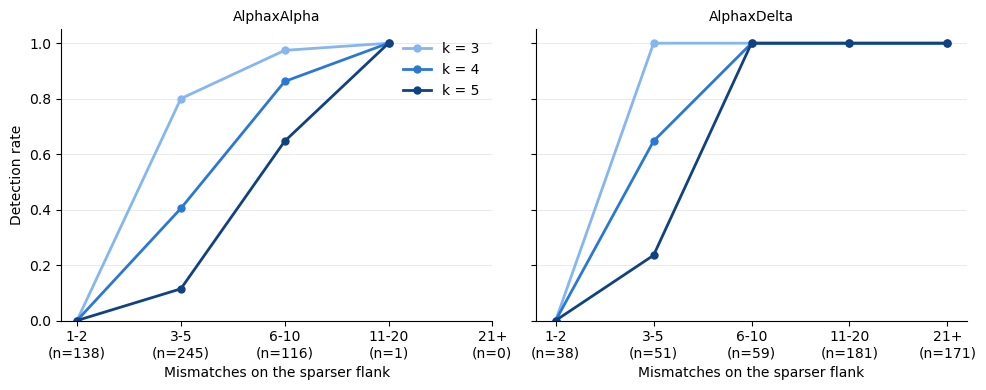

In [6]:
bins = [0, 2, 5, 10, 20, np.inf]
labels = ["1-2", "3-5", "6-10", "11-20", "21+"]

fig, axes = plt.subplots(1, len(crosses), figsize=(10, 4), sharey=True)
for ax, cross in zip(axes, crosses):
    subset = recombinants[recombinants.cross == cross]
    for k in k_values:
        group = subset[subset.k == k].copy()
        group["bin"] = pd.cut(group.min_informative, bins=bins, labels=labels)
        rate = group.groupby("bin", observed=False).detected.mean()
        ax.plot(
            range(len(labels)),
            rate.values,
            marker="o",
            markersize=5,
            linewidth=2,
            color=k_colors[k],
            label=f"k = {k}",
        )
    counts = (
        pd.cut(
            subset[subset.k == k_values[0]].min_informative, bins=bins, labels=labels
        )
        .value_counts()
        .reindex(labels)
    )
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels([f"{label}\n(n={n})" for label, n in counts.items()])
    ax.set_title(cross, fontsize=10)
    ax.set_xlabel("Mismatches on the sparser flank")
    ax.set_ylim(0, 1.05)
    clean_axes(ax)
axes[0].set_ylabel("Detection rate")
axes[0].legend(frameon=False)
fig.tight_layout()

## Net supporting loci

The paper's QC measure, computed the same way: sites where the two inferred parents
differ, clustered into loci when within 3 bases, scored +1 where the recombinant
carries the assigned parent's allele and -1 where it carries the other's. The shaded
region is the failing one, fewer than 4 net loci on either flank.

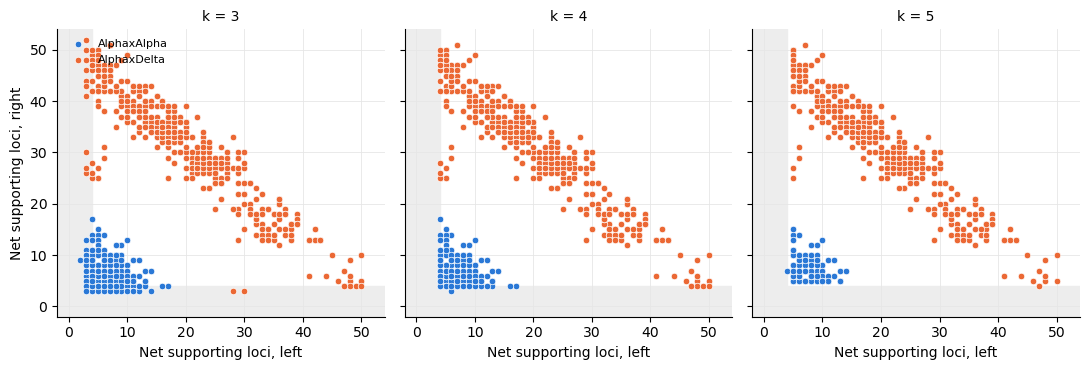

In [7]:
fig, axes = plt.subplots(1, len(k_values), figsize=(11, 3.8), sharex=True, sharey=True)
detected = df[df.detected]
limit = max(detected.net_min_supporting_loci_lft.max(),
            detected.net_min_supporting_loci_rgt.max()) + 2
for ax, k in zip(axes, k_values):
    ax.axhspan(-limit, QC_CUTOFF, color="0.93", zorder=0)
    ax.axvspan(-limit, QC_CUTOFF, color="0.93", zorder=0)
    for cross in crosses:
        subset = detected[(detected.k == k) & (detected.cross == cross)]
        ax.scatter(
            subset.net_min_supporting_loci_lft,
            subset.net_min_supporting_loci_rgt,
            s=22,
            color=cross_colors[cross],
            edgecolor="white",
            linewidth=0.5,
            label=cross,
            zorder=3,
        )
    false_positives_k = detected[(detected.k == k) & (detected.type == "control")]
    if len(false_positives_k) > 0:
        ax.scatter(
            false_positives_k.net_min_supporting_loci_lft,
            false_positives_k.net_min_supporting_loci_rgt,
            s=40,
            marker="X",
            color="#e34948",
            edgecolor="white",
            linewidth=0.5,
            label="false positive",
            zorder=4,
        )
    ax.set_title(f"k = {k}", fontsize=10)
    ax.set_xlabel("Net supporting loci, left")
    ax.set_xlim(-2, limit)
    ax.set_ylim(-2, limit)
    clean_axes(ax)
    ax.xaxis.grid(True, **grid_kwargs)
axes[0].set_ylabel("Net supporting loci, right")
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout()

## Breakpoint intervals

The interval is the region between the last site supporting the left parent and the
first supporting the right, computed by `sc2ts.inference.characterise_recombinants`,
the same function the inference pipeline calls.

The paper reports a median interval of 2,018 bases for the real ARG (dashed line), and
a negative relationship between interval width and the divergence between the parents.
The two crosses reproduce that relationship and bracket the real median: Alpha x Alpha,
whose parents sit at pangonet distance 0, gives much wider intervals than Alpha x Delta
at distance 4-5. Closer parents leave fewer sites to pin the breakpoint against.

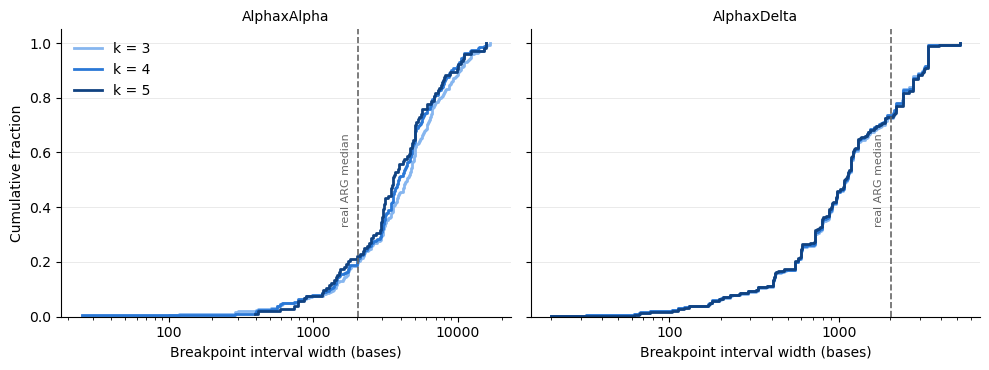

In [8]:
fig, axes = plt.subplots(1, len(crosses), figsize=(10, 3.8), sharey=True)
for ax, cross in zip(axes, crosses):
    subset = detected[(detected.cross == cross) & (detected.type == "recombinant")]
    for k in k_values:
        width = np.sort(subset[subset.k == k].interval_width.values)
        if len(width) == 0:
            continue
        ax.step(
            width,
            np.arange(1, len(width) + 1) / len(width),
            where="post",
            linewidth=2,
            color=k_colors[k],
            label=f"k = {k}",
        )
    ax.axvline(PAPER_MEDIAN_INTERVAL, color="0.4", linestyle="--", linewidth=1.2)
    ax.annotate(
        "real ARG median",
        xy=(PAPER_MEDIAN_INTERVAL, 0.5),
        xytext=(-5, 0),
        textcoords="offset points",
        rotation=90,
        ha="right",
        va="center",
        fontsize=8,
        color="0.4",
    )
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_title(cross, fontsize=10)
    ax.set_xlabel("Breakpoint interval width (bases)")
    ax.set_ylim(0, 1.05)
    clean_axes(ax)
axes[0].set_ylabel("Cumulative fraction")
axes[0].legend(frameon=False, loc="upper left")
fig.tight_layout()

In [9]:
quartiles = (
    detected[detected.type == "recombinant"]
    .groupby(["cross", "k"])
    .interval_width.describe()[["min", "25%", "50%", "75%", "max"]]
)
quartiles.round(0)

min     25%     50%     75%      max
cross       k                                        
AlphaxAlpha 3   25.0  2516.0  4406.0  6597.0  16719.0
            4   25.0  2370.0  3861.0  6110.0  15718.0
            5  396.0  2324.0  3540.0  5597.0  15718.0
AlphaxDelta 3   20.0   602.0  1122.0  2152.0   5151.0
            4   20.0   602.0  1112.0  2120.0   5151.0
            5   20.0   602.0  1080.0  2179.0   5151.0

## HMM cost

A single-parent match pays no recombination penalty, so control costs do not vary with
$k$. Recombinant cost sits at $k$ plus any extra mutations, which pushes some genuine
recombinants past the `hmm_cost_threshold = 7` used in the real inference, regardless
of whether the recombination itself was found.

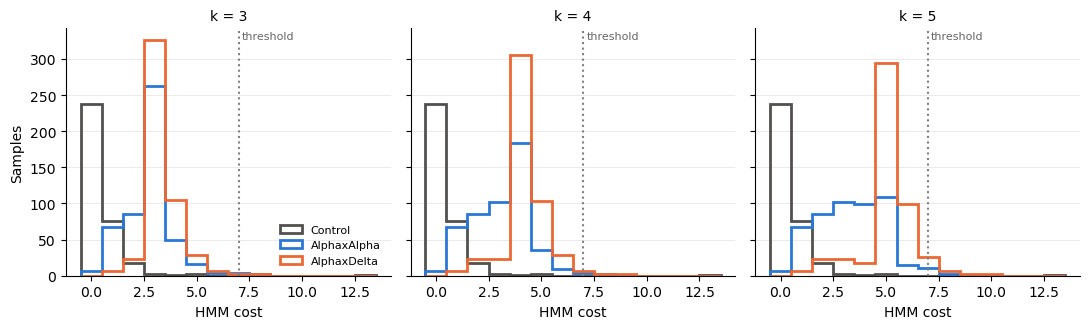

In [10]:
fig, axes = plt.subplots(1, len(k_values), figsize=(11, 3.4), sharey=True)
edges = np.arange(-0.5, 14)
for ax, k in zip(axes, k_values):
    series = [("Control", controls[controls.k == k].hmm_cost, control_color)]
    series += [
        (cross, recombinants[(recombinants.k == k) & (recombinants.cross == cross)].hmm_cost,
         cross_colors[cross])
        for cross in crosses
    ]
    for label, data, color in series:
        ax.hist(data, bins=edges, histtype="step", linewidth=2, color=color, label=label)
    ax.axvline(HMM_COST_THRESHOLD, color="0.5", linestyle=":", linewidth=1.5)
    ax.annotate(
        "threshold",
        xy=(HMM_COST_THRESHOLD, ax.get_ylim()[1]),
        xytext=(2, -2),
        textcoords="offset points",
        va="top",
        fontsize=8,
        color="0.4",
    )
    ax.set_title(f"k = {k}", fontsize=10)
    ax.set_xlabel("HMM cost")
    clean_axes(ax)
axes[0].set_ylabel("Samples")
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout()

In [11]:
above_threshold = (
    df.assign(above=df.hmm_cost > HMM_COST_THRESHOLD)
    .groupby(["type", "cross", "k"], dropna=False)
    .above.mean()
    .unstack("k")
)
above_threshold.round(3)

k                            3      4      5
type        cross                           
control     NaN          0.003  0.003  0.003
recombinant AlphaxAlpha  0.004  0.008  0.008
            AlphaxDelta  0.006  0.010  0.022

## Were the correct parents found?

Detection only says that a recombinant was matched to two parents, not that they were
the right ones. Each detected recombinant's two parents are compared with the true
ones, midway along each matched segment:

- **Pango lineage.** An assigned parent node takes its own Pango lineage if it is a
  sample, otherwise the most common among its descendant samples, and is compared with
  the true parent's.
- **Steps.** The true parents are not in the ARG, so each was matched directly
  (unmutated, $k = 4$) to find the node it would attach to. `steps` is the number of
  edges between that node and the assigned parent in the local tree.
- **Differences.** A different node is not necessarily a wrong one: over a segment
  holding none of the sites that separate them, the two cannot be told apart. `diffs`
  counts the sites within the matched segment at which they differ.

Rates below are per detected recombinant, so both sides must agree.

In [12]:
detected_recombinants = recombinants[recombinants.detected]
rows = []
for (cross, k), group in detected_recombinants.groupby(["cross", "k"]):
    steps = pd.concat([group.left_parent_steps, group.right_parent_steps])
    relations = pd.concat([group.left_parent_relation, group.right_parent_relation])
    rows.append(
        {
            "cross": cross,
            "k": k,
            "n": len(group),
            "pango_correct": (group.left_pango_correct & group.right_pango_correct).mean(),
            "same_node": (
                (group.left_parent_steps == 0) & (group.right_parent_steps == 0)
            ).mean(),
            "indistinguishable": (
                (group.left_parent_diffs == 0) & (group.right_parent_diffs == 0)
            ).mean(),
            "max_diffs": max(group.left_parent_diffs.max(), group.right_parent_diffs.max()),
            "median_steps": steps.median(),
            "max_steps": steps.max(),
            **{f"relation_{name}": (relations == name).mean()
               for name in ["same", "ancestor", "descendant", "other"]},
        }
    )
parent_accuracy = pd.DataFrame(rows).set_index(["cross", "k"])
parent_accuracy.round(3)

n  pango_correct  same_node  indistinguishable  max_diffs  \
cross       k                                                                
AlphaxAlpha 3  310          1.000      0.265              0.810        4.0   
            4  200          1.000      0.340              0.870        4.0   
            5  104          1.000      0.394              0.904        3.0   
AlphaxDelta 3  462          0.870      0.184              0.842        2.0   
            4  444          0.885      0.191              0.856        2.0   
            5  423          0.898      0.199              0.863        2.0   

               median_steps  max_steps  relation_same  relation_ancestor  \
cross       k                                                              
AlphaxAlpha 3           0.0       15.0          0.560              0.344   
            4           0.0       11.0          0.615              0.325   
            5           0.0       10.0          0.654              0.327   
AlphaxDelta 3           0.0       15.0          0.511              0.360   
            4           0.0       15.0          0.512              0.372   
            5           0.0       14.0          0.512              0.385   

               relation_descendant  relation_other  
cross       k                                       
AlphaxAlpha 3                0.005           0.092  
            4                0.002           0.058  
            5                0.005           0.014  
AlphaxDelta 3                0.002           0.127  
            4                0.001           0.115  
            5                0.001           0.102

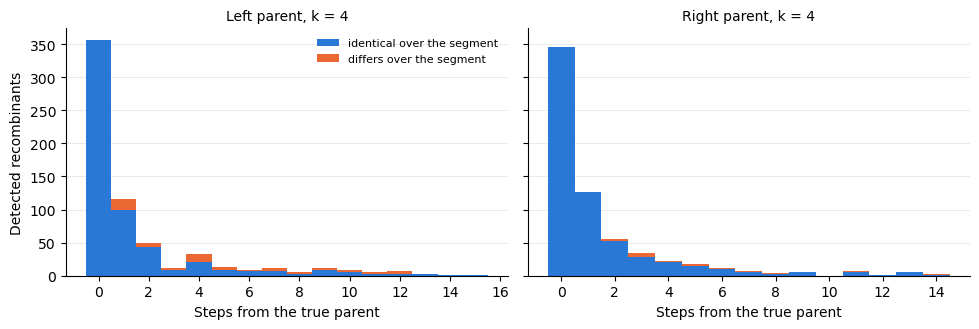

In [13]:
# Steps per side at k = 4, split by whether the assigned parent can be told apart
# from the true one over the matched segment.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
group = detected_recombinants[detected_recombinants.k == 4]
for ax, side in zip(axes, ["left", "right"]):
    steps = group[f"{side}_parent_steps"]
    same = group[f"{side}_parent_diffs"] == 0
    edges = np.arange(-0.5, steps.max() + 1.5)
    ax.hist([steps[same], steps[~same]], bins=edges, stacked=True,
            color=["#2a78d6", "#eb6834"],
            label=["identical over the segment", "differs over the segment"])
    ax.set_title(f"{side.capitalize()} parent, k = 4", fontsize=10)
    ax.set_xlabel("Steps from the true parent")
    clean_axes(ax)
axes[0].set_ylabel("Detected recombinants")
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout()

Both parents are assigned the correct Pango lineage in every detected Alpha x Alpha
recombinant, which is a weak test since these parents are all B.1.1.7, and in 89% of
Alpha x Delta recombinants at $k = 4$. Every error is in a Delta parent, and nearly all
are closely related Delta lineages (pangonet distance 1-2, such as AY.5 assigned AY.4,
or AY.8 assigned B.1.617.2). The exceptions are short Delta segments at the start of
the genome matched to a deep ancestral node, whose descendants are mostly B.1.418.

Both assigned parents are exactly the true parents' attachment nodes in only 19-34% of
detected recombinants, but this mostly reflects what the segment can resolve rather
than error. In 86-87% of detected recombinants, both assigned parents are identical to
the true parents' attachment nodes at every site within the matched segment. No
assigned parent differs at more than 4 sites. When the assigned node is not the
attachment node, it is usually an ancestor, which carries the same alleles over a
segment that holds none of the mutations below it. Adding mutations to the parents
(below) has essentially no effect on any of these measures.

## Unsampled parents

Every arm has the same parent pairs, breakpoints and controls, so differences between
arms are due to the added mutations alone. `detection_rate` is the fraction matched to
more than one parent, which for controls is the false positive rate; `qc_pass_rate` is
the fraction of those that clear the QC gate. `above_cost_threshold` is the fraction
whose HMM cost exceeds the `hmm_cost_threshold = 7` used in the real inference.

In [14]:
by_arm = df_all.assign(group=df_all.cross.fillna("control"))
groups = ["control"] + crosses
rows = []
for (group_name, m, k), group in by_arm.groupby(["group", "mutation_multiplier", "k"]):
    detected_group = group[group.detected]
    rows.append(
        {
            "group": group_name,
            "multiplier": m,
            "k": k,
            "n": len(group),
            "mean_added_mutations": group.num_added_mutations.mean(),
            "detection_rate": group.detected.mean(),
            "qc_pass_rate": detected_group[QC_COLUMN].mean(),
            "breakpoint_in_interval": detected_group.breakpoint_in_interval.mean(),
            "median_interval_width": detected_group.interval_width.median(),
            "median_cost": group.hmm_cost.median(),
            "above_cost_threshold": (group.hmm_cost > HMM_COST_THRESHOLD).mean(),
            "pango_correct": (
                detected_group.left_pango_correct & detected_group.right_pango_correct
            ).mean(),
            "parents_indistinguishable": (
                (detected_group.left_parent_diffs == 0)
                & (detected_group.right_parent_diffs == 0)
            ).mean(),
        }
    )
by_multiplier = pd.DataFrame(rows).set_index(["group", "multiplier", "k"])
by_multiplier.loc[groups].round(3)

n  mean_added_mutations  detection_rate  \
group       multiplier k                                              
control     0          3  338                 0.000           0.000   
                       4  338                 0.000           0.000   
                       5  338                 0.000           0.000   
            1          3  338                 0.343           0.000   
                       4  338                 0.343           0.000   
                       5  338                 0.343           0.000   
            5          3  338                 1.698           0.000   
                       4  338                 1.698           0.000   
                       5  338                 1.698           0.000   
            10         3  338                 3.740           0.000   
                       4  338                 3.740           0.000   
                       5  338                 3.740           0.000   
AlphaxAlpha 0          3  500                 0.000           0.620   
                       4  500                 0.000           0.400   
                       5  500                 0.000           0.208   
            1          3  500                 0.346           0.620   
                       4  500                 0.346           0.400   
                       5  500                 0.346           0.208   
            5          3  500                 1.896           0.626   
                       4  500                 1.896           0.400   
                       5  500                 1.896           0.208   
            10         3  500                 3.664           0.636   
                       4  500                 3.664           0.406   
                       5  500                 3.664           0.212   
AlphaxDelta 0          3  500                 0.000           0.924   
                       4  500                 0.000           0.888   
                       5  500                 0.000           0.846   
            1          3  500                 0.308           0.924   
                       4  500                 0.308           0.888   
                       5  500                 0.308           0.846   
            5          3  500                 1.798           0.926   
                       4  500                 1.798           0.888   
                       5  500                 1.798           0.848   
            10         3  500                 3.550           0.924   
                       4  500                 3.550           0.888   
                       5  500                 3.550           0.848   

                         qc_pass_rate breakpoint_in_interval  \
group       multiplier k                                       
control     0          3         <NA>                   <NA>   
                       4         <NA>                   <NA>   
                       5         <NA>                   <NA>   
            1          3         <NA>                   <NA>   
                       4         <NA>                   <NA>   
                       5         <NA>                   <NA>   
            5          3         <NA>                   <NA>   
                       4         <NA>                   <NA>   
                       5         <NA>                   <NA>   
            10         3         <NA>                   <NA>   
                       4         <NA>                   <NA>   
                       5         <NA>                   <NA>   
AlphaxAlpha 0          3     0.706452               0.964516   
                       4        0.995                  0.995   
                       5          1.0                    1.0   
            1          3     0.706452               0.964516   
                       4        0.995                  0.995   
                       5          1.0                    1.0   
            5          3     0.702875            

/tmp/ipykernel_17504/1953457020.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  (rates.detection_rate * rates.qc_pass_rate.fillna(0)).values,
/tmp/ipykernel_17504/1953457020.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  (rates.detection_rate * rates.qc_pass_rate.fillna(0)).values,
/tmp/ipykernel_17504/1953457020.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('f

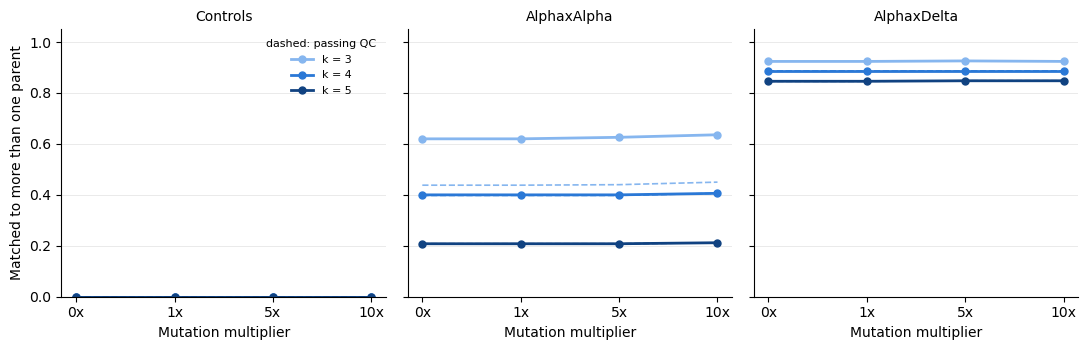

In [15]:
fig, axes = plt.subplots(1, len(groups), figsize=(11, 3.6), sharey=True)
for ax, group_name in zip(axes, groups):
    for k in k_values:
        rates = by_multiplier.loc[(group_name, slice(None), k)]
        ax.plot(
            range(len(multipliers)),
            rates.detection_rate.values,
            marker="o",
            markersize=5,
            linewidth=2,
            color=k_colors[k],
            label=f"k = {k}",
        )
        # Detected and passing the QC gate.
        ax.plot(
            range(len(multipliers)),
            (rates.detection_rate * rates.qc_pass_rate.fillna(0)).values,
            linestyle="--",
            linewidth=1.2,
            color=k_colors[k],
        )
    ax.set_xticks(range(len(multipliers)))
    ax.set_xticklabels([f"{m}x" for m in multipliers])
    ax.set_title(group_name if group_name != "control" else "Controls", fontsize=10)
    ax.set_xlabel("Mutation multiplier")
    ax.set_ylim(0, 1.05)
    clean_axes(ax)
axes[0].set_ylabel("Matched to more than one parent")
axes[0].legend(frameon=False, title="dashed: passing QC", title_fontsize=8, fontsize=8)
fig.tight_layout()

Even at 10x, about 3.6 added mutations per sequence, detection barely moves: the
detection rate for each cross and $k$ shifts by at most 8 recombinants in 500 (1.6
percentage points). No control is matched to more than one parent in any arm.

What does change is cost. Recombinant costs rise with the multiplier, and at 10x with
$k = 4$ the cost of 54% of Alpha x Delta and 38% of Alpha x Alpha recombinants exceeds
`hmm_cost_threshold = 7`, against 1% of each at 0x; 7% of controls also exceed it. As
with the 0x arm, this happens whether or not the recombination itself was found.

## Paper figure

The supplementary figure combines the main results: detection and false positives
against $k$ (A), the dependence of detection on the signal available on the sparser
flank (B), breakpoint interval widths at the paper's $k = 4$ (C), and the effect of
unsampled parents at $k = 4$ (D).

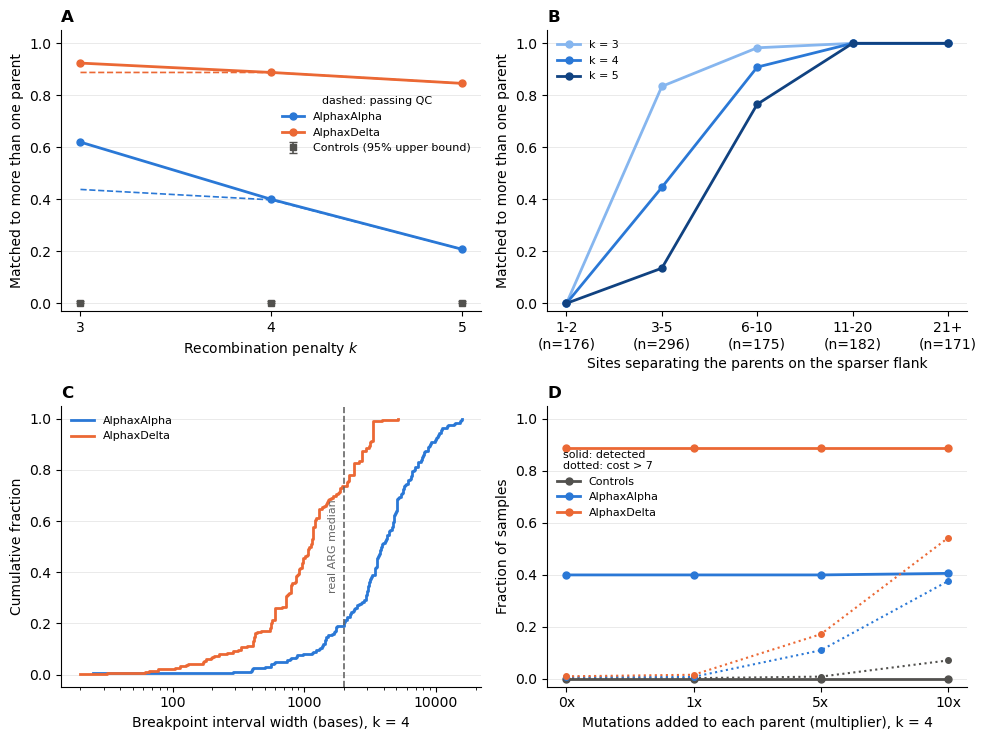

In [16]:
PAPER_K = 4
fig, axes = plt.subplots(2, 2, figsize=(10, 7.5))
ax_k, ax_signal, ax_interval, ax_arm = axes.flat

# A: detection against k, with QC-passing detections dashed, and controls at the
# bottom with their 95% upper bound.
for cross in crosses:
    rates = detection.loc[cross]
    ax_k.plot(k_values, rates.detection_rate, marker="o", markersize=5, linewidth=2,
              color=cross_colors[cross], label=cross)
    ax_k.plot(k_values, rates.detection_rate * rates.qc_pass_rate, linestyle="--",
              linewidth=1.2, color=cross_colors[cross])
ax_k.errorbar(
    k_values,
    false_positives.fp_rate,
    yerr=[np.zeros(len(k_values)), false_positives.fp_upper_95 - false_positives.fp_rate],
    marker="s", markersize=5, linewidth=0, elinewidth=1.2, capsize=3,
    color=control_color, label="Controls (95% upper bound)",
)
ax_k.set_xticks(k_values)
ax_k.set_xlabel("Recombination penalty $k$")
ax_k.set_ylabel("Matched to more than one parent")
ax_k.legend(frameon=False, fontsize=8, title="dashed: passing QC", title_fontsize=8,
            loc="upper right", bbox_to_anchor=(1, 0.8))

# B: detection against the number of sites separating the parents on the sparser
# side of the true breakpoint, both crosses pooled.
for k in k_values:
    group = recombinants[recombinants.k == k]
    rate = group.groupby(
        pd.cut(group.min_informative, bins=bins, labels=labels), observed=False
    ).detected.mean()
    ax_signal.plot(range(len(labels)), rate.values, marker="o", markersize=5,
                   linewidth=2, color=k_colors[k], label=f"k = {k}")
counts = (
    pd.cut(recombinants[recombinants.k == k_values[0]].min_informative,
           bins=bins, labels=labels)
    .value_counts()
    .reindex(labels)
)
ax_signal.set_xticks(range(len(labels)))
ax_signal.set_xticklabels([f"{label}\n(n={n})" for label, n in counts.items()])
ax_signal.set_xlabel("Sites separating the parents on the sparser flank")
ax_signal.set_ylabel("Matched to more than one parent")
ax_signal.legend(frameon=False, fontsize=8)

# C: breakpoint interval widths at k = 4.
for cross in crosses:
    width = np.sort(
        recombinants[
            (recombinants.cross == cross) & (recombinants.k == PAPER_K) & recombinants.detected
        ].interval_width.values
    )
    ax_interval.step(width, np.arange(1, len(width) + 1) / len(width), where="post",
                     linewidth=2, color=cross_colors[cross], label=cross)
ax_interval.axvline(PAPER_MEDIAN_INTERVAL, color="0.4", linestyle="--", linewidth=1.2)
ax_interval.annotate("real ARG median", xy=(PAPER_MEDIAN_INTERVAL, 0.5), xytext=(-5, 0),
                     textcoords="offset points", rotation=90, ha="right", va="center",
                     fontsize=8, color="0.4")
ax_interval.set_xscale("log")
ax_interval.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax_interval.xaxis.set_minor_formatter(mticker.NullFormatter())
ax_interval.set_xlabel(f"Breakpoint interval width (bases), k = {PAPER_K}")
ax_interval.set_ylabel("Cumulative fraction")
ax_interval.legend(frameon=False, fontsize=8, loc="upper left")

# D: unsampled parents at k = 4. Detection solid, cost above the inclusion
# threshold dotted.
for group_name in groups:
    rates = by_multiplier.loc[(group_name, slice(None), PAPER_K)]
    color = control_color if group_name == "control" else cross_colors[group_name]
    label = "Controls" if group_name == "control" else group_name
    ax_arm.plot(range(len(multipliers)), rates.detection_rate.values, marker="o",
                markersize=5, linewidth=2, color=color, label=label)
    ax_arm.plot(range(len(multipliers)), rates.above_cost_threshold.values, marker="o",
                markersize=4, linestyle=":", linewidth=1.5, color=color)
ax_arm.set_xticks(range(len(multipliers)))
ax_arm.set_xticklabels([f"{m}x" for m in multipliers])
ax_arm.set_xlabel(f"Mutations added to each parent (multiplier), k = {PAPER_K}")
ax_arm.set_ylabel("Fraction of samples")
ax_arm.legend(frameon=False, fontsize=8, loc="upper left", bbox_to_anchor=(0, 0.88),
              title=f"solid: detected\ndotted: cost > {HMM_COST_THRESHOLD}",
              title_fontsize=8)

for ax, letter in zip(axes.flat, "ABCD"):
    if ax is not ax_interval:
        ax.set_ylim(-0.03, 1.05)
    clean_axes(ax)
    ax.set_title(letter, loc="left", fontweight="bold")
fig.tight_layout()
fig.savefig("../figures/synthetic_recombinants.pdf")

## Caveats

- Breakpoints are drawn uniformly over the window in which they are detectable at all,
  rather than over the genome. Recombinants whose breakpoint leaves one flank identical
  to both parents are excluded by construction, since no value of $k$ could recover
  them. `detectable_window` records the span that was sampled.
- Parents are contemporaneous sequences from a single day, so the divergence between
  them is fixed by the choice of cross rather than drawn from the pandemic. Breakpoint
  interval widths are therefore not directly comparable to the real ARG's.
- Added mutations are uniform over the genome, with no mutational spectrum or rate
  variation.
- Controls bound the false positive rate from above; they cannot establish that it is
  zero.